# P8 — Notebook 5: Qualitative Figures (Hero Image + Failure Modes + DSSP Probe + Spectral Maps)

**Goal**: Generate the four pixel-domain figures missing from the manuscript draft. Reviewers at IEEE TIP expect to *see* what the framework is talking about — bounding-box overlays, over-smoothing vs artifact injection, band-masked images, and the FFT difference map. Currently every figure in the paper is an analytical plot; this notebook fills that gap.

| Figure | Role in the paper |
|---|---|
| **A** — Hero qualitative grid | Section IV / V intro — visual anchor for the whole framework |
| **B** — Failure modes | Section III.E + V.D — validates the two-mode diagnostic |
| **C** — Band-masked images | Section III.C — visualizes the DSSP probe (Def. 4) |
| **D** — Spectral preservation map | Section III.B — visualizes $\rho_k$ (Def. 5) |

**Inputs already on Drive** (no recompute):
- 5 detector checkpoints (`{detector}_noisy_noise_0/weights/best.pt`)
- 15 deep denoise model `.pt` files (autoencoder/dncnn/cae_pso × σ ∈ {1,5,10,20,30})
- α profile YAML (`alpha_profile_yolov8m_pnplo.yaml`)
- PnPLO test split (235 images + labels) for the hero image

**Outputs** (vector PDFs, IEEE TIP style verbatim from NB1/NB3):
- `P8_outputs/paper_figures/P8_fig_qual_hero.pdf` — Fig A
- `P8_outputs/paper_figures/P8_fig_qual_failmodes.pdf` — Fig B
- `P8_outputs/paper_figures/P8_fig_qual_bandmasks.pdf` — Fig C
- `P8_outputs/paper_figures/P8_fig_qual_spectrum.pdf` — Fig D

**Convention** (matches NB4): BGR end-to-end via cv2, MD5-deterministic noise, sliding-window 128/112 patches for deep methods. ITU-R BT.601 luminance for BFPI/masking. Compute: ~8–15 min on Colab A100 (most time = generating 5 denoise variants of the hero image + 1 failure-mode variant).

**Resume-safe**: heavy cells skip if their PDF already exists. To force re-render, set `FORCE_RERENDER=True` in Cell 2 or `!rm` the PDF.

---

## Cell 1 — Setup + IEEE TIP figure style (verbatim NB1 v5 Cell 13)

In [2]:
# Cell 1: Setup
import os, sys, time, gc, json, yaml, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
from PIL import Image
from scipy import fft as sp_fft
from torchvision import transforms

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects
from matplotlib.patches import Rectangle, Circle
from matplotlib.lines import Line2D

# Mount Drive
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Running outside Colab — paths must be accessible directly')

# Install ultralytics (matches NB2/NB4 versions)
if IN_COLAB:
    os.system('pip install -q "ultralytics==8.4.51" bm3d >/dev/null 2>&1')
from ultralytics import YOLO
import bm3d as bm3d_lib

# --- IEEE TIP figure style: VERBATIM from NB1 v5 Cell 13 ---
mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 8, 'axes.labelsize': 8, 'axes.titlesize': 8,
    'legend.fontsize': 6.5, 'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'axes.linewidth': 0.6, 'lines.linewidth': 1.0,
    'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.dpi': 600, 'savefig.bbox': 'tight',
})
COL1, COL2 = 3.5, 7.16

OI = {'orange':'#E69F00','sky':'#56B4E9','green':'#009E73',
      'blue':'#0072B2','verm':'#D55E00','purple':'#CC79A7','yellow':'#F0E442'}
METHOD_LABEL = {'bm3d':'BM3D','dncnn':'DnCNN','autoencoder':'AE',
                'cae_pso':'CAE+PSO','gaussian_filter':'Gaussian'}
METHOD_ORDER = ['bm3d','dncnn','autoencoder','cae_pso','gaussian_filter']

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE} | torch {torch.__version__}')


Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cpu | torch 2.10.0+cpu


## Cell 2 — Config (Drive paths matching NB1–NB4)

In [3]:
# Cell 2: Config — paths match NB1/NB2/NB3/NB4
DRIVE_ROOT = Path('/content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT')

PNPLO_ROOT        = DRIVE_ROOT / '04_RESULT_TRAIN_KARTHY' / 'YOLO_Denoise_Experiment_Karthy'
CLEAN_TEST_IMAGES = PNPLO_ROOT / 'dataset_yolo' / 'images' / 'test'
CLEAN_TEST_LABELS = PNPLO_ROOT / 'dataset_yolo' / 'labels' / 'test'
TRAINING_RUNS     = PNPLO_ROOT / 'yolo_denoise_experiment' / 'training_runs'
DENOISE_MODELS_DIR= PNPLO_ROOT / 'yolo_denoise_experiment' / 'denoise_models'

# alpha profile (NB2)
ALPHA_YAML = PNPLO_ROOT / 'P8_outputs' / 'alpha_profile_yolov8m_pnplo.yaml'

# output figure dir (shared with NB1 v5 / NB3 v2)
FIG_DIR = DRIVE_ROOT / 'P8_outputs' / 'paper_figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# === Settings ===
DETECTORS = ['yolov8m','yolov9m','yolov10m','yolo11m','yolo12m']
HERO_DETECTOR = 'yolov8m'       # primary detector for predictions in Fig A/B
SIGMA_HERO    = 20              # moderate-noise regime for Fig A
SIGMA_FAIL    = 30              # high-noise regime for Fig B
DENOISE_METHODS = ['bm3d','dncnn','autoencoder','cae_pso','gaussian_filter']
DEEP_METHODS    = ['autoencoder','dncnn','cae_pso']
K_BANDS = 4

# Hero image — set explicitly OR leave None to auto-pick from test split
HERO_IMAGE_NAME = None          # e.g. 'frame_000123.jpg'
AUTO_PICK_MIN_CONF = 0.50

# Force-rerun toggles
FORCE_RERENDER = True

print('=== Path sanity ===')
for label, p, is_dir in [
    ('test images',       CLEAN_TEST_IMAGES, True),
    ('test labels',       CLEAN_TEST_LABELS, True),
    ('detector ckpt dir', TRAINING_RUNS,     True),
    ('deep model dir',    DENOISE_MODELS_DIR,True),
    ('alpha YAML',        ALPHA_YAML,        False),
    ('output FIG_DIR',    FIG_DIR,           True),
]:
    ok = '\u2713' if p.exists() else '\u274c'
    extra = ''
    if is_dir and p.exists():
        try: extra = f' ({sum(1 for _ in p.iterdir())} entries)'
        except: pass
    print(f'  {ok} {label}: {p}{extra}')


=== Path sanity ===
  ✓ test images: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/dataset_yolo/images/test (235 entries)
  ✓ test labels: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/dataset_yolo/labels/test (235 entries)
  ✓ detector ckpt dir: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/yolo_denoise_experiment/training_runs (288 entries)
  ✓ deep model dir: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/yolo_denoise_experiment/denoise_models (20 entries)
  ✓ alpha YAML: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/P8_outputs/alpha_profile_yolov8m_pnplo.yaml
  ✓ output FIG_DIR: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/P8_outputs/paper_figures (6 entries)


## Cell 3 — Load deep denoise models (verbatim NB4 Cell 1)

In [4]:
# Cell 3: Deep architectures + load .pt files — VERBATIM from NB4 Cell 1
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3,64,3,padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64,64,3,padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128,128,3,padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2))
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128,128,2,stride=2), nn.ReLU(inplace=True),
            nn.Conv2d(128,64,3,padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64,64,2,stride=2), nn.ReLU(inplace=True),
            nn.Conv2d(64,3,3,padding=1), nn.Sigmoid())
    def forward(self, x): return self.decoder(self.encoder(x))

class DnCNN(nn.Module):
    def __init__(self, channels=3, num_layers=17, features=64):
        super().__init__()
        layers = [nn.Conv2d(channels, features, 3, padding=1, bias=False), nn.ReLU(inplace=True)]
        for _ in range(num_layers-2):
            layers += [nn.Conv2d(features,features,3,padding=1,bias=False),
                       nn.BatchNorm2d(features), nn.ReLU(inplace=True)]
        layers.append(nn.Conv2d(features,channels,3,padding=1,bias=False))
        self.layers = nn.Sequential(*layers)
    def forward(self, x): return x - self.layers(x)

class CAE(nn.Module):
    def __init__(self, base_filters=64, kernel_size=3):
        super().__init__()
        pad = kernel_size//2; f1, f2 = base_filters, base_filters*2
        self.encoder = nn.Sequential(
            nn.Conv2d(3,f1,kernel_size,padding=pad), nn.BatchNorm2d(f1), nn.ReLU(inplace=True),
            nn.Conv2d(f1,f1,kernel_size,padding=pad), nn.BatchNorm2d(f1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),
            nn.Conv2d(f1,f2,kernel_size,padding=pad), nn.BatchNorm2d(f2), nn.ReLU(inplace=True),
            nn.Conv2d(f2,f2,kernel_size,padding=pad), nn.BatchNorm2d(f2), nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2))
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(f2,f2,2,stride=2), nn.BatchNorm2d(f2), nn.ReLU(inplace=True),
            nn.Conv2d(f2,f1,kernel_size,padding=pad), nn.BatchNorm2d(f1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(f1,f1,2,stride=2), nn.BatchNorm2d(f1), nn.ReLU(inplace=True),
            nn.Conv2d(f1,3,kernel_size,padding=pad), nn.Sigmoid())
    def forward(self, x): return self.decoder(self.encoder(x))

def _infer_cae(sd):
    w = sd.get('encoder.0.weight')
    return {'base_filters': w.shape[0], 'kernel_size': w.shape[2]} if w is not None \
        else {'base_filters':64, 'kernel_size':3}

def _build(method, sd):
    if method == 'autoencoder': m = DenoisingAutoencoder()
    elif method == 'dncnn':     m = DnCNN(channels=3, num_layers=17, features=64)
    elif method == 'cae_pso':   m = CAE(**_infer_cae(sd))
    else: raise ValueError(method)
    m.load_state_dict(sd)
    return m.eval().to(DEVICE)

denoise_models = {m: {} for m in DEEP_METHODS}
SIGMAS_LOAD = sorted({SIGMA_HERO, SIGMA_FAIL})
print(f'Loading deep models for sigma in {SIGMAS_LOAD} (saves memory vs all 15):')
for method in DEEP_METHODS:
    for s in SIGMAS_LOAD:
        p = DENOISE_MODELS_DIR / f'{method}_sigma{s}.pt'
        assert p.exists(), f'missing: {p}'
        try:    sd = torch.load(p, map_location=DEVICE, weights_only=True)
        except: sd = torch.load(p, map_location=DEVICE, weights_only=False)
        denoise_models[method][s] = _build(method, sd)
        print(f'  \u2713 {method}_sigma{s}.pt')

total = sum(len(v) for v in denoise_models.values())
print(f'\n\u2713 {total} deep models on {DEVICE}')


Loading deep models for sigma in [20, 30] (saves memory vs all 15):
  ✓ autoencoder_sigma20.pt
  ✓ autoencoder_sigma30.pt
  ✓ dncnn_sigma20.pt
  ✓ dncnn_sigma30.pt
  ✓ cae_pso_sigma20.pt
  ✓ cae_pso_sigma30.pt

✓ 6 deep models on cpu


## Cell 4 — Denoise + noise + BFPI helpers (verbatim NB4)

In [5]:
# Cell 4: Denoise + noise + BFPI — VERBATIM convention from NB4

def add_noise(clean_bgr, sigma, fname):
    # MD5-seeded AWGN matches NB1/NB4 exactly
    h = hashlib.md5(f'{fname}_{sigma}'.encode()).hexdigest()
    rng = np.random.RandomState(int(h[:8], 16))
    noise = rng.randn(*clean_bgr.shape) * sigma
    return np.clip(clean_bgr.astype(np.float64) + noise, 0, 255).astype(np.uint8)

def denoise_gaussian_filter(img_bgr, sigma):
    if sigma is None or sigma <= 1: ksize = 3
    elif sigma <= 5:  ksize = 5
    elif sigma <= 15: ksize = 7
    else:             ksize = 9
    return cv2.GaussianBlur(img_bgr, (ksize, ksize), 0)

def denoise_bm3d(img_bgr, sigma=10):
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float64) / 255.0
    out = bm3d_lib.bm3d_rgb(rgb, sigma_psd=max(sigma/255.0, 0.01))
    out = np.clip(out*255, 0, 255).astype(np.uint8)
    return cv2.cvtColor(out, cv2.COLOR_RGB2BGR)

def denoise_with_model_fast(image_bgr, model, patch_size=128, stride=112, batch_size=64):
    model.eval()
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    h, w, c = rgb.shape
    pad_h = (patch_size - h % patch_size) % patch_size
    pad_w = (patch_size - w % patch_size) % patch_size
    padded = np.pad(rgb, ((0,pad_h),(0,pad_w),(0,0)), mode='reflect')
    ph, pw = padded.shape[:2]
    out = np.zeros((ph,pw,c), dtype=np.float64)
    cnt = np.zeros((ph,pw,1), dtype=np.float64)
    tx = transforms.ToTensor()
    patches, positions = [], []
    for y in range(0, ph-patch_size+1, stride):
        for x in range(0, pw-patch_size+1, stride):
            patches.append(tx(padded[y:y+patch_size, x:x+patch_size]))
            positions.append((y, x))
    with torch.no_grad():
        # amp autocast available on CUDA only
        if DEVICE == 'cuda':
            ctx = torch.amp.autocast('cuda')
        else:
            from contextlib import nullcontext
            ctx = nullcontext()
        with ctx:
            for i in range(0, len(patches), batch_size):
                batch = torch.stack(patches[i:i+batch_size]).to(DEVICE)
                outs = model(batch).cpu().numpy()
                for j, (y, x) in enumerate(positions[i:i+batch_size]):
                    out[y:y+patch_size, x:x+patch_size] += outs[j].transpose(1, 2, 0)
                    cnt[y:y+patch_size, x:x+patch_size] += 1
    cnt = np.maximum(cnt, 1)
    out = (out / cnt)[:h,:w]
    out = np.clip(out*255, 0, 255).astype(np.uint8)
    return cv2.cvtColor(out, cv2.COLOR_RGB2BGR)

def apply_denoise(method, sigma, img_bgr):
    if method == 'bm3d':            return denoise_bm3d(img_bgr, sigma)
    if method == 'gaussian_filter': return denoise_gaussian_filter(img_bgr, sigma)
    return denoise_with_model_fast(img_bgr, denoise_models[method][sigma])

# ---- BFPI library (verbatim NB1 Cell 2) ----
def get_band_boundaries(K=4):
    b = np.linspace(0, np.pi, K+1); b[-1] = np.inf; return b

def radial_frequency_map(H, W):
    fy = np.fft.fftshift(np.fft.fftfreq(H)) * 2*np.pi
    fx = np.fft.fftshift(np.fft.fftfreq(W)) * 2*np.pi
    fxx, fyy = np.meshgrid(fx, fy, indexing='xy')
    return np.sqrt(fxx**2 + fyy**2)

def band_energy_1ch(img1ch, boundaries, rm):
    F = np.fft.fftshift(sp_fft.fft2(img1ch.astype(np.float64)))
    power = np.abs(F)**2
    return np.array([power[(rm >= boundaries[k]) & (rm < boundaries[k+1])].sum()
                     for k in range(len(boundaries)-1)])

def compute_rho_phase_1ch(clean, denoised, boundaries, rm, eps=1e-10):
    Fc = np.fft.fftshift(sp_fft.fft2(clean.astype(np.float64)))
    Fd = np.fft.fftshift(sp_fft.fft2(denoised.astype(np.float64)))
    dpow = np.abs(Fc - Fd)**2
    D = np.array([dpow[(rm >= boundaries[k]) & (rm < boundaries[k+1])].sum()
                  for k in range(len(boundaries)-1)])
    E = np.abs(Fc)**2
    E_band = np.array([E[(rm >= boundaries[k]) & (rm < boundaries[k+1])].sum()
                       for k in range(len(boundaries)-1)])
    return 1.0 - np.sqrt(D / (E_band + eps)), E_band

def compute_rho_ratio_1ch(clean, denoised, boundaries, rm, eps=1e-10):
    E_c = band_energy_1ch(clean, boundaries, rm)
    E_d = band_energy_1ch(denoised, boundaries, rm)
    return E_d / (E_c + eps)

def bgr_to_luminance(bgr_uint8):
    # ITU-R BT.601 from cv2 BGR uint8: Y = 0.299*R + 0.587*G + 0.114*B
    b = bgr_uint8.astype(np.float64)
    return 0.299*b[..., 2] + 0.587*b[..., 1] + 0.114*b[..., 0]

# ---- Band-masking in luminance only (verbatim NB2 Cell 6) ----
RGB2YCBCR = np.array([[0.299,0.587,0.114],
                      [-0.168736,-0.331264,0.5],
                      [0.5,-0.418688,-0.081312]], dtype=np.float64)
YCBCR2RGB = np.linalg.inv(RGB2YCBCR)
YCBCR_OFFSET = np.array([0.0,128.0,128.0], dtype=np.float64)

def mask_band_in_luminance(bgr_uint8, k, K=4):
    # Mask band k in Y only, preserve Cb/Cr. Input/output: BGR uint8
    rgb = cv2.cvtColor(bgr_uint8, cv2.COLOR_BGR2RGB).astype(np.float64)
    ycbcr = rgb @ RGB2YCBCR.T + YCBCR_OFFSET
    y, cb, cr = ycbcr[...,0], ycbcr[...,1], ycbcr[...,2]
    F = np.fft.fftshift(sp_fft.fft2(y))
    bnd = get_band_boundaries(K)
    rmap = radial_frequency_map(*y.shape)
    Fm = F.copy(); Fm[(rmap >= bnd[k-1]) & (rmap < bnd[k])] = 0.0
    ym = np.real(sp_fft.ifft2(np.fft.ifftshift(Fm)))
    rgb_out = np.clip((np.stack([ym,cb,cr],-1) - YCBCR_OFFSET) @ YCBCR2RGB.T, 0, 255)
    return cv2.cvtColor(rgb_out.astype(np.uint8), cv2.COLOR_RGB2BGR)

print('\u2713 denoise + noise + BFPI + band-mask functions loaded')


✓ denoise + noise + BFPI + band-mask functions loaded


## Cell 5 — Pick hero image + load GT labels + load primary detector

The hero image must:
1. Live in PnPLO test split (so it matches the 235-image set the paper validates on).
2. Contain at least one visible person GT box.
3. Be detected confidently by `yolov8m` on the clean version (conf ≥ 0.5) — otherwise the "noisy degrades detection" narrative has no baseline.

If `HERO_IMAGE_NAME` is set in Cell 2, that image is used directly. Otherwise the cell loops through the test split in alphabetical order and picks the first one that passes.

In [8]:
# Cell 5 (v3 — strict pedestrian-only hero, self-contained):
# inlines iou_xyxy, per_image_f1, predict_yolov8m, BOUNDARIES so Cell 5 runs immediately after Cell 4

yolov8m_model = YOLO(str(TRAINING_RUNS / f'{HERO_DETECTOR}_noisy_noise_0' / 'weights' / 'best.pt'))
print(f'\u2713 Loaded {HERO_DETECTOR} from clean-training run')
class_names = yolov8m_model.names
print(f'  classes: {class_names}')

def read_yolo_labels(label_path, img_h, img_w):
    if not label_path.exists(): return []
    out = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5: continue
            cls = int(parts[0])
            xc, yc, w, h = map(float, parts[1:5])
            x1 = (xc - w/2) * img_w; y1 = (yc - h/2) * img_h
            x2 = (xc + w/2) * img_w; y2 = (yc + h/2) * img_h
            out.append({'cls':cls, 'x1':x1, 'y1':y1, 'x2':x2, 'y2':y2})
    return out

# === Inlined helpers (will be redefined in Cell 7, no harm) ===
def _iou_xyxy(a, b):
    ix1 = max(a[0], b[0]); iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2]); iy2 = min(a[3], b[3])
    iw = max(0.0, ix2 - ix1); ih = max(0.0, iy2 - iy1)
    inter = iw * ih
    if inter == 0: return 0.0
    aA = (a[2]-a[0]) * (a[3]-a[1]); aB = (b[2]-b[0]) * (b[3]-b[1])
    return inter / (aA + aB - inter)

def _per_image_f1(preds, gts, iou_thr=0.5):
    if len(gts) == 0 and len(preds) == 0: return 1.0
    if len(gts) == 0: return 0.0
    if len(preds) == 0: return 0.0
    matched_g = set(); tp = 0
    preds_sorted = sorted(preds, key=lambda x: -x.get('conf', 1.0))
    for p in preds_sorted:
        best_iou, best_g = 0, -1
        for gi, g in enumerate(gts):
            if gi in matched_g: continue
            v = _iou_xyxy((p['x1'],p['y1'],p['x2'],p['y2']),
                          (g['x1'],g['y1'],g['x2'],g['y2']))
            if v > best_iou: best_iou, best_g = v, gi
        if best_iou >= iou_thr and best_g >= 0:
            tp += 1; matched_g.add(best_g)
    fp = len(preds) - tp; fn = len(gts) - tp
    P = tp/(tp+fp) if (tp+fp) else 0.0
    R = tp/(tp+fn) if (tp+fn) else 0.0
    return 2*P*R/(P+R) if (P+R) > 0 else 0.0

def _predict_yolov8m(bgr_img, conf=0.25):
    rgb = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    r = yolov8m_model.predict(rgb, conf=conf, iou=0.5, verbose=False, device=DEVICE)[0]
    out = []
    if r.boxes is None or len(r.boxes) == 0: return out
    xyxy = r.boxes.xyxy.cpu().numpy()
    confs = r.boxes.conf.cpu().numpy()
    cls_arr = r.boxes.cls.cpu().numpy().astype(int)
    for i in range(len(xyxy)):
        out.append({'x1':float(xyxy[i,0]),'y1':float(xyxy[i,1]),
                    'x2':float(xyxy[i,2]),'y2':float(xyxy[i,3]),
                    'conf':float(confs[i]),'cls':int(cls_arr[i])})
    return out

_BOUNDARIES_v3 = get_band_boundaries(K=4)

def find_hero(min_conf=AUTO_PICK_MIN_CONF, force_name=HERO_IMAGE_NAME,
              min_gt_boxes=2, max_smallest_box_frac=0.10,
              person_cls=0, bm3d_ratio_threshold=0.5,
              expensive_top_n=30):
    """
    v3 strict criteria:
    - GT boxes must be class 'person' (cls==0), NOT 'person-like' (cls==1)
    - >=2 GT pedestrians, smallest box <= 10% area
    - BM3D sigma=20 F1 < clean F1 (denoising must not help)
    - BM3D sigma=30 rho_4^ratio < 0.5 (caption claim 'over-smoothing' is honest)
    """
    candidates = sorted(CLEAN_TEST_IMAGES.glob('*.jpg'))
    if force_name is not None:
        cand = CLEAN_TEST_IMAGES / force_name
        assert cand.exists(), f'HERO_IMAGE_NAME not in test split: {force_name}'
        return cand

    print(f'v3 PASS 1: cheap filter on {len(candidates)} test images...')
    print(f'  cheap: \u2265{min_gt_boxes} GT (cls==person ONLY), smallest \u2264{max_smallest_box_frac*100:.0f}%, conf\u2265{min_conf}')
    cheap_pass = []
    for p in candidates:
        img = cv2.imread(str(p))
        if img is None: continue
        H, W = img.shape[:2]; img_area = H * W
        gt_all = read_yolo_labels(CLEAN_TEST_LABELS / (p.stem + '.txt'), H, W)
        gt_person = [g for g in gt_all if g['cls'] == person_cls]
        if len(gt_person) < min_gt_boxes: continue
        smallest_frac = min((g['x2']-g['x1'])*(g['y2']-g['y1']) for g in gt_person) / img_area
        if smallest_frac > max_smallest_box_frac: continue
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        res = yolov8m_model.predict(rgb, conf=0.25, verbose=False, device=DEVICE)[0]
        if res.boxes is None or len(res.boxes) == 0: continue
        if res.boxes.conf.cpu().numpy().max() < min_conf: continue
        cheap_pass.append((p, gt_person, smallest_frac, len(gt_person) / (smallest_frac + 0.01)))

    cheap_pass.sort(key=lambda t: -t[3])
    print(f'  \u2713 {len(cheap_pass)} pass cheap filter')

    if not cheap_pass:
        raise RuntimeError('No image passes cheap filter -- relax min_gt_boxes or max_smallest_box_frac')

    top_n = min(expensive_top_n, len(cheap_pass))
    print(f'\nv3 PASS 2: expensive filter on top-{top_n} candidates...')
    print(f'  expensive: BM3D_s20 F1 < clean F1  AND  BM3D_s30 rho_4_ratio < {bm3d_ratio_threshold}')

    for rank, (p, gt_person, sf, score) in enumerate(cheap_pass[:top_n], 1):
        img = cv2.imread(str(p))
        H, W = img.shape[:2]
        clean_f1 = _per_image_f1(_predict_yolov8m(img), gt_person)
        if clean_f1 < 0.30:
            print(f'  [skip #{rank:2d}] {p.name:32}  clean F1={clean_f1:.2f} too low')
            continue
        # BM3D sigma=20
        bm3d_s20 = denoise_bm3d(add_noise(img, 20, p.name), 20)
        bm3d_s20_f1 = _per_image_f1(_predict_yolov8m(bm3d_s20), gt_person)
        if bm3d_s20_f1 >= clean_f1:
            print(f'  [skip #{rank:2d}] {p.name:32}  '
                  f'BM3D_s20 F1={bm3d_s20_f1:.2f} \u2265 clean={clean_f1:.2f}  (denoising helps)')
            continue
        # BM3D sigma=30 + rho_4^ratio
        bm3d_s30 = denoise_bm3d(add_noise(img, 30, p.name), 30)
        clean_lum_loc = bgr_to_luminance(img)
        den_lum_loc   = bgr_to_luminance(bm3d_s30)
        rmap_loc      = radial_frequency_map(H, W)
        r_ratio = compute_rho_ratio_1ch(clean_lum_loc, den_lum_loc, _BOUNDARIES_v3, rmap_loc)
        if r_ratio[3] >= bm3d_ratio_threshold:
            print(f'  [skip #{rank:2d}] {p.name:32}  '
                  f'BM3D_s30 rho_4_ratio={r_ratio[3]:.2f} \u2265 {bm3d_ratio_threshold}')
            continue

        print(f'\n  \u2713 STRICT MATCH (rank {rank}): {p.name}')
        print(f'    {len(gt_person)} GT person, smallest = {sf*100:.1f}% area')
        print(f'    clean F1 = {clean_f1:.2f}  >  BM3D_s20 F1 = {bm3d_s20_f1:.2f}  (denoising hurts \u2713)')
        print(f'    BM3D_s30 rho_4_ratio = {r_ratio[3]:.3f}  <  {bm3d_ratio_threshold}  (over-smoothing \u2713)')
        return p

    print(f'\n  [warn] no strict v3 match in top-{top_n}; falling back to highest-scored cheap-pass image')
    print(f'  using: {cheap_pass[0][0].name}')
    return cheap_pass[0][0]

hero_path = find_hero()
print(f'\n\u2713 HERO IMAGE: {hero_path.name}')
hero_clean_bgr = cv2.imread(str(hero_path))
hero_h, hero_w = hero_clean_bgr.shape[:2]
print(f'  shape: {hero_clean_bgr.shape}')

hero_gt = read_yolo_labels(CLEAN_TEST_LABELS / (hero_path.stem + '.txt'), hero_h, hero_w)
print(f'  GT boxes: {len(hero_gt)}')
for g in hero_gt:
    box_area_frac = (g["x2"]-g["x1"])*(g["y2"]-g["y1"]) / (hero_h*hero_w)
    cls_name = class_names.get(g["cls"], g["cls"])
    print(f'    cls={cls_name}: ({g["x1"]:.0f},{g["y1"]:.0f}) -> ({g["x2"]:.0f},{g["y2"]:.0f})  '
          f'({box_area_frac*100:.1f}% of image)')

✓ Loaded yolov8m from clean-training run
  classes: {0: 'person', 1: 'person-like'}
v3 PASS 1: cheap filter on 235 test images...
  cheap: ≥2 GT (cls==person ONLY), smallest ≤10%, conf≥0.5
  ✓ 40 pass cheap filter

v3 PASS 2: expensive filter on top-30 candidates...
  expensive: BM3D_s20 F1 < clean F1  AND  BM3D_s30 rho_4_ratio < 0.5

  ✓ STRICT MATCH (rank 1): image (119).jpg
    15 GT person, smallest = 1.1% area
    clean F1 = 0.56  >  BM3D_s20 F1 = 0.40  (denoising hurts ✓)
    BM3D_s30 rho_4_ratio = 0.229  <  0.5  (over-smoothing ✓)

✓ HERO IMAGE: image (119).jpg
  shape: (375, 500, 3)
  GT boxes: 15
    cls=person: (91,107) -> (169,371)  (11.0% of image)
    cls=person: (157,114) -> (211,370)  (7.4% of image)
    cls=person: (188,96) -> (260,363)  (10.3% of image)
    cls=person: (236,88) -> (292,361)  (8.2% of image)
    cls=person: (287,83) -> (352,351)  (9.3% of image)
    cls=person: (329,90) -> (380,353)  (7.2% of image)
    cls=person: (376,100) -> (425,342)  (6.3% of image

## Cell 6 — Generate hero variants (1 noisy + 5 denoised at $\sigma=20$, plus $\sigma=30$ pair for failure modes)

Per the paper, $\sigma=20$ is the *moderate* regime where DnCNN peaks anomalously at $|\Delta F_1|=0.171$ — a representative case for Fig A. Fig B needs $\sigma=30$ to show strong BM3D over-smoothing and DnCNN artifact injection.

In [9]:
# Cell 6: Generate hero variants — 5 denoised at sigma_hero + BM3D/DnCNN at sigma_fail
fname = hero_path.name

variants = {'clean': hero_clean_bgr}

print(f'\n--- sigma = {SIGMA_HERO} (Fig A: hero qualitative grid) ---')
hero_noisy = add_noise(hero_clean_bgr, SIGMA_HERO, fname)
variants[f'noisy_s{SIGMA_HERO}'] = hero_noisy
for m in DENOISE_METHODS:
    t0 = time.time()
    den = apply_denoise(m, SIGMA_HERO, hero_noisy)
    variants[f'{m}_s{SIGMA_HERO}'] = den
    print(f'  \u2713 {m:16}  {time.time()-t0:.2f}s')

print(f'\n--- sigma = {SIGMA_FAIL} (Fig B: failure modes) ---')
hero_noisy_fail = add_noise(hero_clean_bgr, SIGMA_FAIL, fname)
variants[f'noisy_s{SIGMA_FAIL}'] = hero_noisy_fail
for m in ('bm3d','dncnn'):
    t0 = time.time()
    den = apply_denoise(m, SIGMA_FAIL, hero_noisy_fail)
    variants[f'{m}_s{SIGMA_FAIL}'] = den
    print(f'  \u2713 {m:16}  {time.time()-t0:.2f}s')

print(f'\n\u2713 {len(variants)} variants ready: {sorted(variants.keys())}')



--- sigma = 20 (Fig A: hero qualitative grid) ---
  ✓ bm3d              44.21s
  ✓ dncnn             5.74s
  ✓ autoencoder       1.89s
  ✓ cae_pso           1.11s
  ✓ gaussian_filter   0.01s

--- sigma = 30 (Fig B: failure modes) ---
  ✓ bm3d              44.85s
  ✓ dncnn             5.75s

✓ 10 variants ready: ['autoencoder_s20', 'bm3d_s20', 'bm3d_s30', 'cae_pso_s20', 'clean', 'dncnn_s20', 'dncnn_s30', 'gaussian_filter_s20', 'noisy_s20', 'noisy_s30']


## Cell 7 — Compute per-variant predictions + $\rho_k$ + per-image $|\Delta F_1|$

For each variant we run `yolov8m.predict()` to get bounding boxes (used by the overlays in Fig A/B). For each denoised variant we also compute $\rho_k^{\text{phase}}$ and $\rho_k^{\text{ratio}}$ on the same luminance the paper uses.

Per-image $F_1$ from prediction-vs-GT matching at IoU=0.5 — same threshold as Section IV.

In [10]:
# Cell 7: Predictions + per-image F1 + rho
def iou_xyxy(a, b):
    ix1 = max(a[0], b[0]); iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2]); iy2 = min(a[3], b[3])
    iw = max(0.0, ix2 - ix1); ih = max(0.0, iy2 - iy1)
    inter = iw * ih
    if inter == 0: return 0.0
    aA = (a[2]-a[0]) * (a[3]-a[1]); aB = (b[2]-b[0]) * (b[3]-b[1])
    return inter / (aA + aB - inter)

def per_image_f1(preds, gts, iou_thr=0.5):
    # Greedy matching, returns (F1, TP, FP, FN)
    if len(gts) == 0 and len(preds) == 0: return 1.0, 0, 0, 0
    if len(gts) == 0: return 0.0, 0, len(preds), 0
    if len(preds) == 0: return 0.0, 0, 0, len(gts)
    matched_g = set(); tp = 0
    preds_sorted = sorted(preds, key=lambda x: -x.get('conf', 1.0))
    for p in preds_sorted:
        best_iou = 0; best_g = -1
        for gi, g in enumerate(gts):
            if gi in matched_g: continue
            v = iou_xyxy((p['x1'],p['y1'],p['x2'],p['y2']),
                         (g['x1'],g['y1'],g['x2'],g['y2']))
            if v > best_iou:
                best_iou = v; best_g = gi
        if best_iou >= iou_thr and best_g >= 0:
            tp += 1; matched_g.add(best_g)
    fp = len(preds) - tp; fn = len(gts) - tp
    P = tp / (tp+fp) if (tp+fp) else 0.0
    R = tp / (tp+fn) if (tp+fn) else 0.0
    F1 = 2*P*R/(P+R) if (P+R) > 0 else 0.0
    return F1, tp, fp, fn

def predict_yolov8m(bgr_img, conf=0.25):
    rgb = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    r = yolov8m_model.predict(rgb, conf=conf, iou=0.5, verbose=False, device=DEVICE)[0]
    out = []
    if r.boxes is None or len(r.boxes) == 0: return out
    xyxy = r.boxes.xyxy.cpu().numpy()
    confs = r.boxes.conf.cpu().numpy()
    cls = r.boxes.cls.cpu().numpy().astype(int)
    for i in range(len(xyxy)):
        out.append({'x1':float(xyxy[i,0]),'y1':float(xyxy[i,1]),
                    'x2':float(xyxy[i,2]),'y2':float(xyxy[i,3]),
                    'conf':float(confs[i]),'cls':int(cls[i])})
    return out

BOUNDARIES = get_band_boundaries(K=4)
rm = radial_frequency_map(hero_h, hero_w)
clean_lum = bgr_to_luminance(hero_clean_bgr)

variant_info = {}
clean_F1, *_ = per_image_f1(predict_yolov8m(hero_clean_bgr), hero_gt)
print(f'F1(clean) = {clean_F1:.3f}')

for name, img in variants.items():
    preds = predict_yolov8m(img)
    f1, tp, fp, fn = per_image_f1(preds, hero_gt)
    info = {'preds': preds, 'F1': f1, 'dF1': clean_F1 - f1,
            'tp': tp, 'fp': fp, 'fn': fn}
    if name != 'clean' and not name.startswith('noisy'):
        lum = bgr_to_luminance(img)
        rho_phase, _ = compute_rho_phase_1ch(clean_lum, lum, BOUNDARIES, rm)
        rho_ratio = compute_rho_ratio_1ch(clean_lum, lum, BOUNDARIES, rm)
        info['rho_phase'] = rho_phase
        info['rho_ratio'] = rho_ratio
    variant_info[name] = info
    rho_str = ''
    if 'rho_phase' in info:
        rho_str = '  rho_phase=[' + ', '.join(f'{v:+.2f}' for v in info['rho_phase']) + ']'
    print(f'  {name:25}  F1={f1:.3f}  dF1={info["dF1"]:+.3f}  '
          f'TP={tp} FP={fp} FN={fn}{rho_str}')


F1(clean) = 0.560
  clean                      F1=0.560  dF1=+0.000  TP=7 FP=3 FN=8
  noisy_s20                  F1=0.235  dF1=+0.325  TP=2 FP=0 FN=13
  bm3d_s20                   F1=0.400  dF1=+0.160  TP=4 FP=1 FN=11  rho_phase=[+0.96, +0.67, +0.46, +0.23]
  dncnn_s20                  F1=0.118  dF1=+0.442  TP=1 FP=1 FN=14  rho_phase=[+0.77, +0.41, -0.04, -0.75]
  autoencoder_s20            F1=0.118  dF1=+0.442  TP=1 FP=1 FN=14  rho_phase=[+0.77, +0.38, +0.02, -0.03]
  cae_pso_s20                F1=0.222  dF1=+0.338  TP=2 FP=1 FN=13  rho_phase=[+0.76, +0.38, +0.01, -0.05]
  gaussian_filter_s20        F1=0.118  dF1=+0.442  TP=1 FP=1 FN=14  rho_phase=[+0.92, +0.20, +0.02, +0.01]
  noisy_s30                  F1=0.000  dF1=+0.560  TP=0 FP=1 FN=15
  bm3d_s30                   F1=0.400  dF1=+0.160  TP=4 FP=1 FN=11  rho_phase=[+0.93, +0.56, +0.33, +0.15]
  dncnn_s30                  F1=0.125  dF1=+0.435  TP=1 FP=0 FN=14  rho_phase=[+0.77, +0.24, -0.39, -1.30]


## Cell 8 — Bbox-overlay drawing helpers

GT boxes drawn in green dashed. Matched predictions in orange solid. Unmatched (FP) predictions in vermilion dotted. Unmatched (FN) GT marked with "FN" label.

In [11]:
# Cell 8: Drawing helpers
def draw_image_with_boxes(ax, bgr_img, gt_boxes=None, pred_boxes=None,
                          show_legend=False, title=None, subtitle=None,
                          iou_thr=0.5):
    # Render BGR image with GT (green dash) + Pred (TP orange / FP vermilion)
    rgb = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    ax.imshow(rgb)
    ax.set_xticks([]); ax.set_yticks([])

    matched_pred = set(); matched_gt = set()
    if gt_boxes and pred_boxes:
        preds_sorted = sorted(enumerate(pred_boxes), key=lambda x: -x[1].get('conf', 1.0))
        for pi, p in preds_sorted:
            best_iou, best_g = 0, -1
            for gi, g in enumerate(gt_boxes):
                if gi in matched_gt: continue
                v = iou_xyxy((p['x1'],p['y1'],p['x2'],p['y2']),
                             (g['x1'],g['y1'],g['x2'],g['y2']))
                if v > best_iou: best_iou, best_g = v, gi
            if best_iou >= iou_thr and best_g >= 0:
                matched_pred.add(pi); matched_gt.add(best_g)

    # GT boxes
    if gt_boxes:
        for gi, g in enumerate(gt_boxes):
            ax.add_patch(Rectangle((g['x1'], g['y1']), g['x2']-g['x1'], g['y2']-g['y1'],
                                    fill=False, edgecolor=OI['green'], lw=1.1, linestyle='--'))
            if gi not in matched_gt:
                ax.text(g['x1']+2, g['y1']+12, 'FN', color=OI['verm'],
                        fontsize=5.5, weight='bold',
                        path_effects=[matplotlib.patheffects.withStroke(
                            linewidth=1.4, foreground='white')])

    # Pred boxes
    if pred_boxes:
        for pi, p in enumerate(pred_boxes):
            is_fp = pi not in matched_pred
            color = OI['verm'] if is_fp else OI['orange']
            ls = ':' if is_fp else '-'
            ax.add_patch(Rectangle((p['x1'], p['y1']), p['x2']-p['x1'], p['y2']-p['y1'],
                                    fill=False, edgecolor=color, lw=1.0, linestyle=ls))
            if is_fp:
                ax.text(p['x1']+2, p['y1']+12, 'FP', color=OI['verm'],
                        fontsize=5.5, weight='bold',
                        path_effects=[matplotlib.patheffects.withStroke(
                            linewidth=1.4, foreground='white')])

    if title is not None:
        ax.set_title(title, fontsize=7.5, pad=2.5)
    if subtitle is not None:
        ax.text(0.5, -0.06, subtitle, transform=ax.transAxes,
                ha='center', va='top', fontsize=6.3)

def make_legend_handles():
    return [
        Line2D([0],[0], color=OI['green'],  lw=1.2, ls='--', label='GT box'),
        Line2D([0],[0], color=OI['orange'], lw=1.2, ls='-',  label='True positive'),
        Line2D([0],[0], color=OI['verm'],   lw=1.2, ls=':',  label='False positive'),
        Line2D([0],[0], color='none', marker='$\\mathrm{FN}$', markersize=7,
                markeredgecolor=OI['verm'], label='False negative'),
    ]

print('\u2713 drawing helpers ready')


✓ drawing helpers ready


## Cell 9 — Figure A: Hero qualitative grid (2 rows × 4 cols)

Top row: Clean (with GT) | Noisy $\sigma=20$ | BM3D | DnCNN
Bottom row: Gaussian | AE | CAE+PSO | (legend panel)

Each subtitle reports $|\Delta F_1|$ and the dominant-band $\rho_2$ (band 2 dominates $S$ per Section V.E).

✓ saved → /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/P8_outputs/paper_figures/P8_fig_qual_hero.pdf


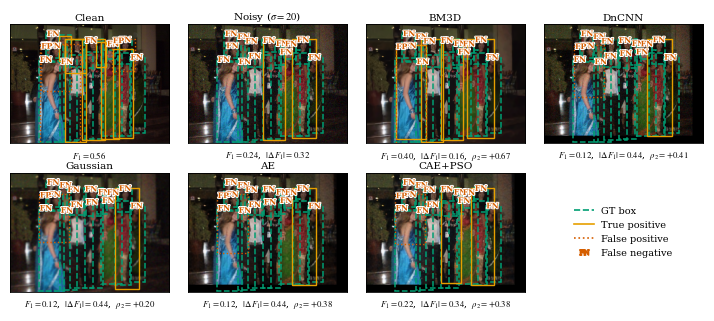

In [12]:
# Cell 9: Figure A — hero qualitative grid
FIG_A_PDF = FIG_DIR / 'P8_fig_qual_hero.pdf'
if FIG_A_PDF.exists() and not FORCE_RERENDER:
    print(f'[skip] {FIG_A_PDF.name} already exists - set FORCE_RERENDER=True to recompute')
else:
    layout = [
        ('clean',                              'Clean',                                 None),
        (f'noisy_s{SIGMA_HERO}',              f'Noisy ($\\sigma={SIGMA_HERO}$)',       None),
        (f'bm3d_s{SIGMA_HERO}',                'BM3D',                                  'bm3d'),
        (f'dncnn_s{SIGMA_HERO}',               'DnCNN',                                 'dncnn'),
        (f'gaussian_filter_s{SIGMA_HERO}',     'Gaussian',                              'gaussian_filter'),
        (f'autoencoder_s{SIGMA_HERO}',         'AE',                                    'autoencoder'),
        (f'cae_pso_s{SIGMA_HERO}',             'CAE+PSO',                               'cae_pso'),
        (None, None, None),  # legend cell
    ]

    fig, axes = plt.subplots(2, 4, figsize=(COL2, COL2 * (hero_h/hero_w) * 0.55))
    axes = axes.flatten()
    for ax, (key, title, method) in zip(axes, layout):
        if key is None:
            ax.axis('off')
            ax.legend(handles=make_legend_handles(), loc='center',
                       frameon=False, handlelength=2.0, fontsize=7)
            continue
        info = variant_info[key]
        img = variants[key]
        if key == 'clean':
            subtitle = f'$F_1 = {info["F1"]:.2f}$'
        elif key.startswith('noisy'):
            subtitle = f'$F_1 = {info["F1"]:.2f}$,  $|\\Delta F_1| = {abs(info["dF1"]):.2f}$'
        else:
            rho2 = info.get('rho_phase', [0,0,0,0])[1]
            subtitle = (f'$F_1 = {info["F1"]:.2f}$,  '
                        f'$|\\Delta F_1| = {abs(info["dF1"]):.2f}$,  '
                        f'$\\rho_2 = {rho2:+.2f}$')
        draw_image_with_boxes(
            ax, img, gt_boxes=hero_gt, pred_boxes=info['preds'],
            title=title, subtitle=subtitle)

    plt.tight_layout(pad=0.4, h_pad=1.2, w_pad=0.4)
    fig.savefig(FIG_A_PDF)
    print(f'\u2713 saved \u2192 {FIG_A_PDF}')
    plt.show()


## Cell 10 — Figure B: Failure modes side-by-side at $\sigma=30$

Three-panel layout: Clean | BM3D over-smoothing | DnCNN artifact injection. Annotation tags the diagnostic band's $\rho_k^{\text{ratio}}$ value in the canonical danger zone ($<0.5$ for over-smoothing, $>1.5$ for artifact injection, per Definition 6).

✓ saved → /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/P8_outputs/paper_figures/P8_fig_qual_failmodes.pdf


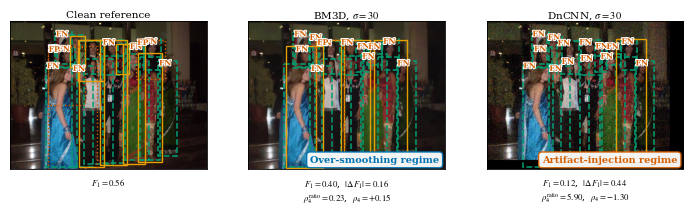

In [13]:
# Cell 10 (v2 — fix annotation readability): Figure B — Failure modes at sigma=30
FIG_B_PDF = FIG_DIR / 'P8_fig_qual_failmodes.pdf'
if FIG_B_PDF.exists() and not FORCE_RERENDER:
    print(f'[skip] {FIG_B_PDF.name} already exists - set FORCE_RERENDER=True to recompute')
else:
    fig, axes = plt.subplots(1, 3, figsize=(COL2, COL2 * (hero_h/hero_w) * 0.34))
    panels = [
        ('clean', 'Clean reference', None, None),
        (f'bm3d_s{SIGMA_FAIL}',  f'BM3D, $\\sigma={SIGMA_FAIL}$',
         'Over-smoothing regime',     OI['blue']),
        (f'dncnn_s{SIGMA_FAIL}', f'DnCNN, $\\sigma={SIGMA_FAIL}$',
         'Artifact-injection regime', OI['verm']),
    ]
    for ax, (key, title, regime_label, tag_color) in zip(axes, panels):
        info = variant_info[key]; img = variants[key]
        if key == 'clean':
            subtitle = f'$F_1 = {info["F1"]:.2f}$'
        else:
            r4_ratio = info.get('rho_ratio', [0,0,0,0])[3]
            r4_phase = info.get('rho_phase', [0,0,0,0])[3]
            subtitle = (f'$F_1 = {info["F1"]:.2f}$,  $|\\Delta F_1| = {abs(info["dF1"]):.2f}$\n'
                        f'$\\rho_4^{{\\mathrm{{ratio}}}} = {r4_ratio:.2f}$,  '
                        f'$\\rho_4 = {r4_phase:+.2f}$')
        draw_image_with_boxes(
            ax, img, gt_boxes=hero_gt, pred_boxes=info['preds'],
            title=title, subtitle=subtitle)
        # v2 FIX: white opaque box + colored border + bold colored text, bottom-right corner
        if regime_label is not None:
            ax.text(0.97, 0.03, regime_label, transform=ax.transAxes,
                    va='bottom', ha='right',
                    fontsize=7.0, weight='bold', color=tag_color,
                    bbox=dict(facecolor='white', alpha=0.95,
                              edgecolor=tag_color, lw=1.0,
                              boxstyle='round,pad=0.35'))

    plt.tight_layout(pad=0.3, w_pad=0.5)
    fig.savefig(FIG_B_PDF)
    print(f'\u2713 saved \u2192 {FIG_B_PDF}')
    plt.show()

## Cell 11 — Figure C: DSSP probe visualization (band-masked images)

Same hero image, but with band $k$ removed from luminance for $k \in \{1,2,3,4\}$. Caption reports $\alpha_k$ from the YAML produced by NB2 plus the $F_1$ drop when YOLOv8m sees the masked image. Reader can now verify visually:
- Band 1 masked → DC component gone, image darkens dramatically → explains why $\alpha_1$ is the largest in Table VI.
- Band 4 masked → barely visible change → explains why $\alpha_4 \approx 0$.

This is the most direct evidence for Section V.E's counter-intuitive low-frequency-dominance finding.

  band 1: F1 (masked) = 0.222,  drop = +0.338
  band 2: F1 (masked) = 0.125,  drop = +0.435
  band 3: F1 (masked) = 0.500,  drop = +0.060
  band 4: F1 (masked) = 0.640,  drop = -0.080

✓ saved → /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/P8_outputs/paper_figures/P8_fig_qual_bandmasks.pdf


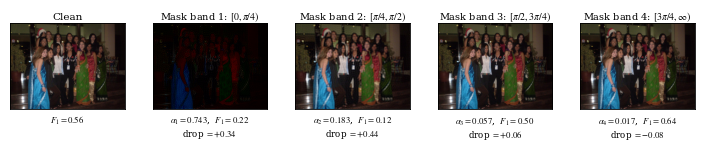

In [14]:
# Cell 11: Figure C — band-masked images + alpha probe F1 drops
FIG_C_PDF = FIG_DIR / 'P8_fig_qual_bandmasks.pdf'
if FIG_C_PDF.exists() and not FORCE_RERENDER:
    print(f'[skip] {FIG_C_PDF.name} already exists - set FORCE_RERENDER=True to recompute')
else:
    if ALPHA_YAML.exists():
        alpha_dict = yaml.safe_load(open(ALPHA_YAML))['alpha']
        alpha = [alpha_dict[f'band_{k}'] for k in [1,2,3,4]]
    else:
        print(f'[warn] alpha YAML not found - will print "alpha_k = ?" placeholders')
        alpha = [None]*4

    band_masked_imgs = {}
    band_f1 = {}
    for k in [1,2,3,4]:
        masked = mask_band_in_luminance(hero_clean_bgr, k=k)
        band_masked_imgs[k] = masked
        preds = predict_yolov8m(masked)
        f1, *_ = per_image_f1(preds, hero_gt)
        band_f1[k] = f1
        print(f'  band {k}: F1 (masked) = {f1:.3f},  drop = {clean_F1 - f1:+.3f}')

    fig, axes = plt.subplots(1, 5, figsize=(COL2, COL2 * (hero_h/hero_w) * 0.22))
    band_label_short = ['$[0,\\pi/4)$','$[\\pi/4,\\pi/2)$',
                        '$[\\pi/2,3\\pi/4)$','$[3\\pi/4,\\infty)$']

    ax = axes[0]
    ax.imshow(cv2.cvtColor(hero_clean_bgr, cv2.COLOR_BGR2RGB))
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title('Clean', fontsize=7.5, pad=2.5)
    ax.text(0.5, -0.06, f'$F_1 = {clean_F1:.2f}$', transform=ax.transAxes,
            ha='center', va='top', fontsize=6.3)

    for kk, ax in enumerate(axes[1:], start=1):
        ax.imshow(cv2.cvtColor(band_masked_imgs[kk], cv2.COLOR_BGR2RGB))
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f'Mask band {kk}: {band_label_short[kk-1]}', fontsize=7.0, pad=2.5)
        a_str = f'{alpha[kk-1]:.3f}' if alpha[kk-1] is not None else '?'
        ax.text(0.5, -0.06,
                f'$\\alpha_{kk} = {a_str}$,  '
                f'$F_1 = {band_f1[kk]:.2f}$\n'
                f'drop $= {clean_F1 - band_f1[kk]:+.2f}$',
                transform=ax.transAxes, ha='center', va='top', fontsize=6.3)

    plt.tight_layout(pad=0.3, w_pad=0.3)
    fig.savefig(FIG_C_PDF)
    print(f'\n\u2713 saved \u2192 {FIG_C_PDF}')
    plt.show()


## Cell 12 — Figure D: Spectral preservation map (FFT spectra + difference)

Four-panel figure for one denoised pair (BM3D at $\sigma=20$ to match the moderate-noise regime in Fig A):
- (a) $\log|\hat{y}|$ — clean magnitude spectrum with band annotations
- (b) $\log|\hat{\hat{y}}|$ — denoised magnitude spectrum
- (c) $\log|\hat{y} - \hat{\hat{y}}|$ — band-wise difference heatmap (viridis)
- (d) Per-band $\rho_k^{\text{phase}}$ bar plot

The concentric circles on (a)–(c) at radii $\pi/4, \pi/2, 3\pi/4$ are the band boundaries from Definition 1.

✓ saved → /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/P8_outputs/paper_figures/P8_fig_qual_spectrum.pdf


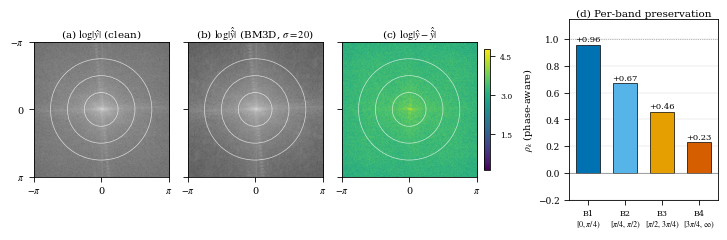

In [15]:
# Cell 12 (v2 — fix label overlap): Figure D — spectral preservation map
FIG_D_PDF = FIG_DIR / 'P8_fig_qual_spectrum.pdf'
if FIG_D_PDF.exists() and not FORCE_RERENDER:
    print(f'[skip] {FIG_D_PDF.name} already exists - set FORCE_RERENDER=True to recompute')
else:
    # Use BM3D sigma=20 pair (visible degradation but no catastrophe - good for didactic)
    den_bgr = variants[f'bm3d_s{SIGMA_HERO}']
    den_lum = bgr_to_luminance(den_bgr)
    Fc = np.fft.fftshift(sp_fft.fft2(clean_lum))
    Fd = np.fft.fftshift(sp_fft.fft2(den_lum))
    Fdiff = Fc - Fd
    rho_phase = variant_info[f'bm3d_s{SIGMA_HERO}']['rho_phase']

    def log_mag(F): return np.log10(np.abs(F) + 1e-3)
    Mc, Md, Mdiff = log_mag(Fc), log_mag(Fd), log_mag(Fdiff)

    vmin_ab = min(Mc.min(), Md.min())
    vmax_ab = max(Mc.max(), Md.max())

    # --- v2 layout: constrained_layout handles colorbar spacing automatically ---
    fig = plt.figure(figsize=(COL2, COL2 * 0.32), constrained_layout=True)
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 1.1])
    axs = [fig.add_subplot(gs[0, i]) for i in range(4)]

    def draw_spectrum(ax, M, title, vmin=None, vmax=None, cmap='gray',
                      show_xticklabels=True, show_yticklabels=True):
        im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax,
                       extent=[-np.pi, np.pi, np.pi, -np.pi])
        ax.set_xticks([-np.pi, 0, np.pi])
        ax.set_yticks([-np.pi, 0, np.pi])
        if show_xticklabels:
            ax.set_xticklabels(['$-\\pi$', '0', '$\\pi$'])
        else:
            ax.set_xticklabels([])
        if show_yticklabels:
            ax.set_yticklabels(['$-\\pi$', '0', '$\\pi$'])
        else:
            ax.set_yticklabels([])
        ax.set_title(title, fontsize=7.5, pad=2)
        for r in [np.pi/4, np.pi/2, 3*np.pi/4]:
            ax.add_patch(Circle((0, 0), r, fill=False, color='white',
                                 lw=0.5, alpha=0.7))
        return im

    # v2 KEY FIX: only panel (a) shows yticklabels; (b), (c) hide them (same range, redundant)
    draw_spectrum(axs[0], Mc, '(a) $\\log|\\hat{y}|$ (clean)',
                  vmin=vmin_ab, vmax=vmax_ab, cmap='gray',
                  show_yticklabels=True)
    draw_spectrum(axs[1], Md, '(b) $\\log|\\hat{\\hat{y}}|$ (BM3D, $\\sigma=20$)',
                  vmin=vmin_ab, vmax=vmax_ab, cmap='gray',
                  show_yticklabels=False)
    im_diff = draw_spectrum(axs[2], Mdiff,
                            '(c) $\\log|\\hat{y} - \\hat{\\hat{y}}|$',
                            cmap='viridis',
                            show_yticklabels=False)

    # v2 KEY FIX: compact colorbar — small fraction + pad, slim aspect, fewer ticks
    cbar = fig.colorbar(im_diff, ax=axs[2], fraction=0.05, pad=0.025,
                         shrink=0.85, aspect=18)
    cbar.ax.tick_params(labelsize=5.5)
    cbar.locator = mpl.ticker.MaxNLocator(nbins=4)
    cbar.update_ticks()

    # (d) bar plot — independent panel, gets full spacing from constrained_layout
    ax = axs[3]
    bands = [1, 2, 3, 4]
    bcol = [OI['blue'], OI['sky'], OI['orange'], OI['verm']]
    bars = ax.bar(bands, rho_phase, width=0.65, color=bcol,
                  edgecolor='black', lw=0.5)
    for b, v in zip(bars, rho_phase):
        ax.text(b.get_x() + b.get_width()/2, max(v, 0) + 0.025,
                f'{v:+.2f}', ha='center', fontsize=6.0)
    ax.axhline(1.0, color='grey', lw=0.5, ls=':')
    ax.axhline(0.0, color='grey', lw=0.5)
    ax.set_xticks(bands)
    band_label_short = ['$[0,\\pi/4)$', '$[\\pi/4,\\pi/2)$',
                        '$[\\pi/2,3\\pi/4)$', '$[3\\pi/4,\\infty)$']
    ax.set_xticklabels([f'B{k}\n{band_label_short[k-1]}' for k in bands],
                        fontsize=5.8)
    ax.set_ylabel(r'$\rho_k$ (phase-aware)', fontsize=7, labelpad=2)
    ax.set_ylim(min(min(rho_phase) - 0.15, -0.2), 1.15)
    ax.set_title('(d) Per-band preservation', fontsize=7.5, pad=2)
    ax.grid(axis='y', lw=0.3, alpha=0.5)
    ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=6.5)

    fig.savefig(FIG_D_PDF)
    print(f'\u2713 saved \u2192 {FIG_D_PDF}')
    plt.show()

## Cell 13 — Summary

In [16]:
# Cell 13: Summary
print('=' * 62)
print('NB5 QUALITATIVE FIGURES - SUMMARY')
print('=' * 62)
print(f'Hero image: {hero_path.name}')
print(f'  shape: {hero_clean_bgr.shape}')
print(f'  GT person boxes: {len(hero_gt)}')
print(f'  F1(clean) on {HERO_DETECTOR}: {clean_F1:.3f}\n')

print('Generated figures:')
for pdf, role in [
    (FIG_DIR / 'P8_fig_qual_hero.pdf',      'Fig A - hero qualitative grid'),
    (FIG_DIR / 'P8_fig_qual_failmodes.pdf', 'Fig B - failure modes (over-smooth vs artifact)'),
    (FIG_DIR / 'P8_fig_qual_bandmasks.pdf', 'Fig C - DSSP band-masked probe'),
    (FIG_DIR / 'P8_fig_qual_spectrum.pdf',  'Fig D - spectral preservation map (BM3D s=20)'),
]:
    ok = '\u2713' if pdf.exists() else '\u274c'
    size = f'{pdf.stat().st_size/1024:.1f} KB' if pdf.exists() else '-'
    print(f'  {ok} {role:55} {size}')

print(f'\nAll 4 PDFs live in: {FIG_DIR}')
print('Download them into Overleaf  figures/  folder alongside the existing P8_fig_*.pdf.')
print('\nManuscript hooks (suggested):')
print('  Fig A -> Section V intro or V-A (validation setup)')
print('  Fig B -> III-E (two-mode diagnostic) or V-D (DnCNN failure)')
print('  Fig C -> III-C (DSSP) or V-E (low-frequency dominance)')
print('  Fig D -> III-B (rho definition) or supplementary')


NB5 QUALITATIVE FIGURES - SUMMARY
Hero image: image (119).jpg
  shape: (375, 500, 3)
  GT person boxes: 15
  F1(clean) on yolov8m: 0.560

Generated figures:
  ✓ Fig A - hero qualitative grid                           5638.3 KB
  ✓ Fig B - failure modes (over-smooth vs artifact)         3406.8 KB
  ✓ Fig C - DSSP band-masked probe                          2421.1 KB
  ✓ Fig D - spectral preservation map (BM3D s=20)           2068.6 KB

All 4 PDFs live in: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/P8_outputs/paper_figures
Download them into Overleaf  figures/  folder alongside the existing P8_fig_*.pdf.

Manuscript hooks (suggested):
  Fig A -> Section V intro or V-A (validation setup)
  Fig B -> III-E (two-mode diagnostic) or V-D (DnCNN failure)
  Fig C -> III-C (DSSP) or V-E (low-frequency dominance)
  Fig D -> III-B (rho definition) or supplementary
